## 环境配置
### 安装配置 R 语言环境

```
## 进入 R 编程环境
conda activate LabelTransfer

## 安装所需库
conda create -n LabelTransfer -c conda-forge \
r-base=4.3 \
hdf5 \
r-hdf5r \
r-seurat \
r-seuratobject \
r-arrow \
r-tidyverse \
r-ggplot2 \
r-ggpmisc \
r-cowplot \
r-gridextra \
r-viridis \
r-hrbrthemes \
r-jsonlite \
r-remotes
```

### 安装BPcells

```
## 下载 BPcells 包
cd ~
git clone https://github.com/bnprks/BPCells.git

## 进入 R 环境
R

## 使用本地编译安装
remotes::install_local("~/BPCells/r")
```

### 安装 ipynb 文件运行 R 所需库

```
## 安装所需库
conda install -c conda-forge \
r-irkernel \
jupyter \
notebook \
ipykernel

## 进入 R 注册 kernel
IRkernel::installspec(name = "LabelTransfer", displayname = "R_LabelTransfer")

##  数据准备

### 在终端中执行，进入你的工作目录

```
cd ./data/
wget https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
unzip Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
```

```
curl -O https://cf.10xgenomics.com/samples/cell-exp/8.0.1/17k_Ovarian_Cancer_scFFPE/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5
```

```
curl -O https://cf.10xgenomics.com/supp/cell-exp/FLEX_Ovarian_Barcode_Cluster_Annotation.csv
```

In [17]:
# ============================================
# Cell 1: 统一初始化 - 集中管理所有配置
# ============================================

# 1. 设置工作目录
setwd("/home/ailab/caohao/AdaDiss/")

# 2. 定义所有文件路径
paths <- list(
    # ===== 输入数据路径 =====
    # Flex 数据
    flex_h5 = "./data/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5",
    flex_annotation = "./data/FLEX_Ovarian_Barcode_Cluster_Annotation.csv",
    flex_bpcells_dir = "./data/flex_counts_bpcells/",
    flex_cache = "./data/flex_data_processed.rds",
    
    # Xenium 数据
    xenium_dir = "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/",
    xenium_bpcells_dir = "./data/xenium_counts_bpcells/",
    xenium_cache = "./data/xenium_data_processed.rds",
    xenium_gene_panel = "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/gene_panel.json",
    
    # ===== 输出数据路径 =====
    # 预测结果导出
    output_csv = "./results/cell_groups.csv",                    # 基础预测结果
    output_full_csv = "./results/cell_predictions_full.csv",     # 完整预测结果（含所有分数列）
    output_rds = "./results/xenium_annotated_final.rds",         # 完整Seurat对象
    output_flex_rds = "./results/flex_reference.rds",            # Flex参考对象（可选）
    
    # 分析中间结果（可选）
    output_stats = "./results/prediction_stats.txt",             # 统计报告
    output_plots = "./results/plots/"                           # 可视化图表保存目录
)

# 3. 设置分析参数
params <- list(
    # Flex QC 参数
    flex_min_counts = 200,
    flex_max_counts = 10000,
    flex_max_mt = 10,
    
    # Xenium 参数
    xenium_npcs = 50,
    xenium_dims = 1:30,
    xenium_resolution = 0.6,
    xenium_cluster_name = "clusters",
    
    # 标签转移参数
    transfer_dims = 1:30,
    transfer_k = 50,
    
    # 可视化参数
    seed = 42,
    
    # 输出控制
    save_intermediate = TRUE,      # 是否保存中间结果
    verbose = TRUE                 # 是否打印详细信息
)

# ========== 关键：细胞类型映射表 ==========
# 4. 将分数列名（点号格式）映射到原始细胞类型名
cell_type_mapping <- c(
    # 分数列名格式 → 原始格式
    "Tumor.Associated.Fibroblasts" = "Tumor Associated Fibroblasts",
    "Endothelial.Cells" = "Endothelial Cells",
    "Stromal.Associated.Fibroblasts" = "Stromal Associated Fibroblasts",
    "T...NK.Cells" = "T & NK Cells",
    "Malignant.Cells.Lining.Cyst" = "Malignant Cells Lining Cyst",
    "Proliferative.Tumor.Cells" = "Proliferative Tumor Cells",
    "Tumor.Cells" = "Tumor Cells",
    "Pericytes" = "Pericytes",
    "Granulosa.Cells" = "Granulosa Cells",
    "Macrophages" = "Macrophages",
    "MT.High..Jun..Fos..Tumor.Cells" = "MT-High, Jun+/Fos+ Tumor Cells",
    "VEGFA..Tumor.Cells" = "VEGFA+ Tumor Cells",
    "Smooth.Muscle.Cells" = "Smooth Muscle Cells",
    "Inflammatory.Tumor.Cells" = "Inflammatory Tumor Cells",
    "Ciliated.Epithelial.Cells" = "Ciliated Epithelial Cells",
    "Fallopian.Tube.Epithelium" = "Fallopian Tube Epithelium"
)

# 反向映射表（原始格式 → 分数列名格式）
reverse_mapping <- setNames(names(cell_type_mapping), cell_type_mapping)

# 打印映射表验证
cat("\n📋 细胞类型映射表:\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
for (i in 1:length(cell_type_mapping)) {
    cat(sprintf("  %-35s → %-40s\n", 
                names(cell_type_mapping)[i], 
                cell_type_mapping[i]))
}
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")


# 5. 创建输出目录（如果不存在）
if (!dir.exists(dirname(paths$output_csv))) {
    dir.create(dirname(paths$output_csv), recursive = TRUE)
    cat("📁 创建输出目录:", dirname(paths$output_csv), "\n")
}

if (!dir.exists(paths$output_plots)) {
    dir.create(paths$output_plots, recursive = TRUE)
    cat("📁 创建图表目录:", paths$output_plots, "\n")
}

# 6. 设置随机种子
set.seed(params$seed)

# 7. 加载所有必要的包
cat("📦 加载R包...\n")
suppressPackageStartupMessages({
    # 核心包
    library(Seurat)
    library(BPCells)
    library(SeuratObject)
    library(SeuratDisk)
    library(tidyverse)
    library(jsonlite)
    
    # 绘图包
    library(ggplot2)
    library(ggpmisc)
    library(scales)
    library(cowplot)
    library(gridExtra)
    library(viridis)
    library(hrbrthemes)
})

# 8. 设置Seurat内存限制
options(future.globals.maxSize = 1e9)

# 9. 定义缓存加载函数
load_or_process <- function(cache_file, process_func, force_reprocess = FALSE) {
    if (!force_reprocess && file.exists(cache_file)) {
        cat("📦 从缓存加载:", basename(cache_file), "\n")
        return(readRDS(cache_file))
    } else {
        if (force_reprocess) cat("🔄 强制重新处理...\n")
        else cat("🔄 首次运行，正在处理...\n")
        obj <- process_func()
        # 确保缓存目录存在
        cache_dir <- dirname(cache_file)
        if (!dir.exists(cache_dir)) {
            dir.create(cache_dir, recursive = TRUE)
        }
        saveRDS(obj, cache_file)
        cat("✅ 已保存到:", basename(cache_file), "\n")
        return(obj)
    }
}

# 10. 打印配置信息
cat("\n✅ 环境初始化完成\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
cat("📁 工作目录:", getwd(), "\n")
cat("\n📂 输入数据路径:\n")
cat("  - Flex数据:", paths$flex_h5, "\n")
cat("  - Flex注释:", paths$flex_annotation, "\n")
cat("  - Xenium数据:", paths$xenium_dir, "\n")
cat("\n📤 输出数据路径:\n")
cat("  - 预测结果:", paths$output_csv, "\n")
cat("  - 完整预测:", paths$output_full_csv, "\n")
cat("  - Seurat对象:", paths$output_rds, "\n")
cat("  - 统计报告:", paths$output_stats, "\n")
cat("  - 图表目录:", paths$output_plots, "\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")


📋 细胞类型映射表:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tumor.Associated.Fibroblasts        → Tumor Associated Fibroblasts            
  Endothelial.Cells                   → Endothelial Cells                       
  Stromal.Associated.Fibroblasts      → Stromal Associated Fibroblasts          
  T...NK.Cells                        → T & NK Cells                            
  Malignant.Cells.Lining.Cyst         → Malignant Cells Lining Cyst             
  Proliferative.Tumor.Cells           → Proliferative Tumor Cells               
  Tumor.Cells                         → Tumor Cells                             
  Pericytes                           → Pericytes                               
  Granulosa.Cells                     → Granulosa Cells                         
  Macrophages                         → Macrophages                             
  MT.High..Jun..Fos..Tumor.Cells      → MT-High, Jun+/Fos+ Tumor Cells          
  VEGFA..Tumor.Cells                  → VEGF

In [2]:
# ============================================
# Cell 2: 加载Flex参考数据（带缓存机制）
# ============================================

process_flex_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    flex_obj <- Read10X_h5(paths$flex_h5) %>% CreateSeuratObject()
    
    cat("  步骤2: 配置BPCells磁盘存储...\n")
    if (!dir.exists(paths$flex_bpcells_dir)) {
        write_matrix_dir(mat = flex_obj[["RNA"]]$counts, dir = paths$flex_bpcells_dir)
    }
    flex_obj[['RNA']]$counts <- open_matrix_dir(dir = paths$flex_bpcells_dir)
    
    cat("  步骤3: 计算线粒体比例...\n")
    flex_obj[["percent.mt"]] <- PercentageFeatureSet(flex_obj, pattern = "^MT-")
    
    cat("  步骤4: QC过滤...\n")
    n_before <- ncol(flex_obj)
    flex_obj <- subset(flex_obj, 
                       subset = nCount_RNA > params$flex_min_counts & 
                                nCount_RNA < params$flex_max_counts & 
                                percent.mt < params$flex_max_mt)
    cat("    过滤前:", n_before, "细胞 → 过滤后:", ncol(flex_obj), "细胞\n")
    
    cat("  步骤5: 添加细胞类型注释...\n")
    if (file.exists(paths$flex_annotation)) {
        ann_df <- read.csv(paths$flex_annotation)
        cell_types <- setNames(ann_df$Cell.Annotation, ann_df$Barcode)
        # 只保留当前数据中存在的细胞
        cell_types <- cell_types[names(cell_types) %in% colnames(flex_obj)]
        flex_obj <- AddMetaData(flex_obj, cell_types[colnames(flex_obj)], "cell_type")
        cat("    注释了", length(unique(flex_obj$cell_type)), "种细胞类型\n")
    } else {
        warning("找不到注释文件: ", paths$flex_annotation)
    }
    
    return(flex_obj)
}

# 加载或处理Flex数据
flex_data.obj <- load_or_process(paths$flex_cache, process_flex_data)

cat("\n📊 Flex数据摘要:\n")
cat("  - 细胞数量:", ncol(flex_data.obj), "\n")
cat("  - 基因数量:", nrow(flex_data.obj), "\n")
cat("  - 细胞类型:", length(unique(flex_data.obj$cell_type)), "\n")

📦 从缓存加载: flex_data_processed.rds 

📊 Flex数据摘要:
  - 细胞数量: 17050 
  - 基因数量: 18082 
  - 细胞类型: 16 


In [3]:
# ============================================
# Cell 3: 加载Xenium数据（带缓存机制）
# ============================================

process_xenium_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    xenium_obj <- LoadXenium(paths$xenium_dir, fov = "fov", molecule.coordinates = FALSE)
    DefaultAssay(xenium_obj) <- "Xenium"
    
    cat("  步骤2: 配置BPCells磁盘存储...\n")
    if (!dir.exists(paths$xenium_bpcells_dir)) {
        write_matrix_dir(mat = xenium_obj[["Xenium"]]$counts, dir = paths$xenium_bpcells_dir)
    }
    xenium_obj[['Xenium']]$counts <- open_matrix_dir(dir = paths$xenium_bpcells_dir)
    
    cat("  步骤3: 过滤空细胞...\n")
    n_before <- ncol(xenium_obj)
    xenium_obj <- subset(xenium_obj, subset = nCount_Xenium > 0)
    cat("    过滤前:", n_before, "细胞 → 过滤后:", ncol(xenium_obj), "细胞\n")
    
    cat("  步骤4: 添加log转换元数据...\n")
    xenium_obj@meta.data$nCount_Xenium_log <- log1p(xenium_obj@meta.data$nCount_Xenium)
    xenium_obj@meta.data$nFeature_Xenium_log <- log1p(xenium_obj@meta.data$nFeature_Xenium)
    
    return(xenium_obj)
}

# 加载或处理Xenium数据
xenium.obj <- load_or_process(paths$xenium_cache, process_xenium_data)

cat("\n📊 Xenium数据摘要:\n")
cat("  - 细胞数量:", ncol(xenium.obj), "\n")
cat("  - 基因数量:", nrow(xenium.obj), "\n")

📦 从缓存加载: xenium_data_processed.rds 

📊 Xenium数据摘要:
  - 细胞数量: 406611 
  - 基因数量: 5101 


📈 计算基因表达相关性...


Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 41 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”


✅ 相关性分析完成


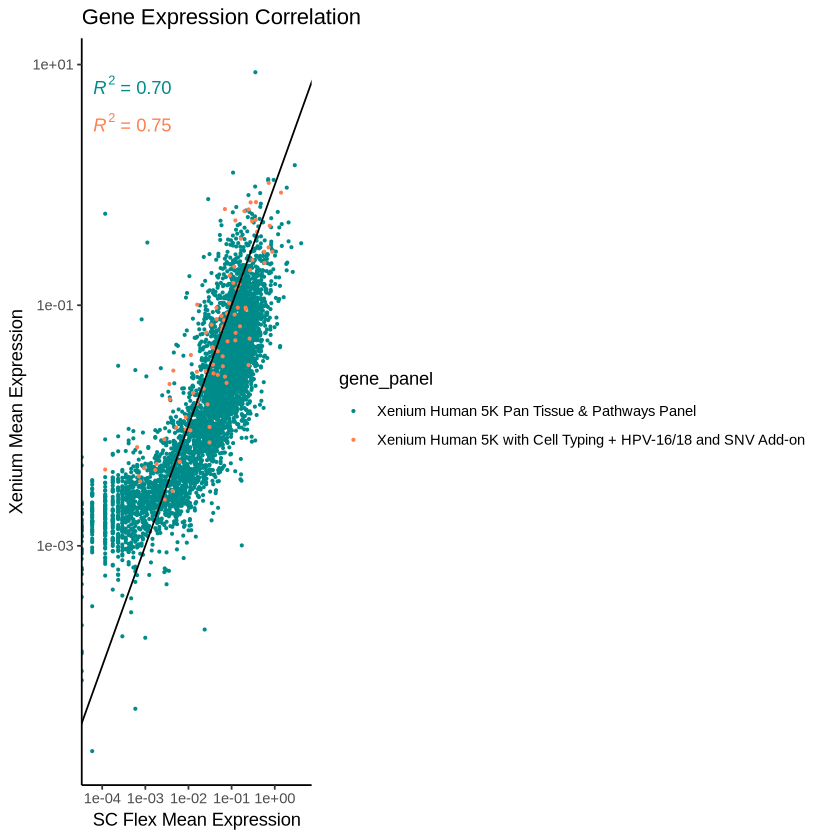

In [4]:
# ============================================
# Cell 4: 基因表达相关性分析（可选，如失败可跳过）
# ============================================

if (file.exists(paths$xenium_gene_panel)) {
    cat("📈 计算基因表达相关性...\n")
    
    # 定义函数
    get_gex_means <- function(xenium_obj, flex_obj) {
        xen_means <- data.frame(
            mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
            gene = rownames(xenium_obj[["Xenium"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
        
        flex_means <- data.frame(
            mean_counts = rowMeans(flex_obj[["RNA"]]$counts),
            gene = rownames(flex_obj[["RNA"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
        
        return(merge(xen_means, flex_means, by.x = "gene", by.y = "gene", all.x = TRUE))
    }
    
    # 读取基因面板
    gene_panel <- fromJSON(paths$xenium_gene_panel)
    targets <- gene_panel$payload$targets
    panel_source <- setNames(
        data.frame(cbind(targets$source$identity$name, targets$type$data$name)), 
        c("gene_panel", "gene")
    )
    
    # 合并数据
    merged_means <- get_gex_means(xenium.obj, flex_data.obj)
    merged_means <- merge(merged_means, panel_source, by.x = "gene", by.y = "gene", all.x = TRUE) %>%
                   na.omit() %>% arrange(gene_panel)
    
    # 绘图
    p_cor <- ggplot(merged_means, aes(x = mean_counts.y, y = mean_counts.x, color = gene_panel)) +
        geom_point(size = 0.5) +
        scale_colour_manual(values = c("darkcyan", "coral")) +
        stat_poly_eq() +
        scale_x_log10() + scale_y_log10() +
        xlab("SC Flex Mean Expression") + ylab("Xenium Mean Expression") +
        ggtitle("Gene Expression Correlation") +
        theme_classic() +
        geom_abline(slope = 1, intercept = 0)
    
    print(p_cor)
    cat("✅ 相关性分析完成\n")
} else {
    cat("⚠️ 跳过相关性分析（找不到gene_panel.json）\n")
}

🔧 处理Flex参考数据...


Normalizing layer: counts

Finding variable features for layer counts

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17050
Number of edges: 598740

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9287
Number of communities: 17
Elapsed time: 4 seconds
✅ Flex数据处理完成


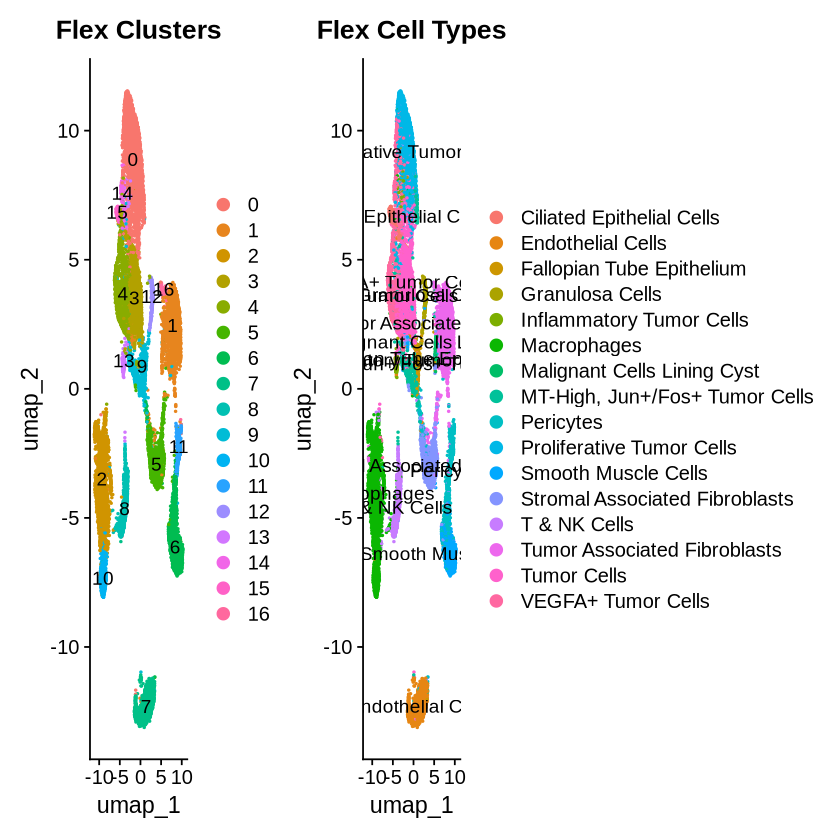

In [5]:
# ============================================
# Cell 5: Flex参考数据处理
# ============================================

cat("🔧 处理Flex参考数据...\n")

DefaultAssay(flex_data.obj) <- "RNA"
flex_data.obj <- NormalizeData(flex_data.obj) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA(verbose = FALSE) %>%
                 RunUMAP(dims = 1:15, verbose = FALSE) %>%
                 FindNeighbors(dims = 1:15) %>%
                 FindClusters(resolution = 0.5)

# 可视化
p1 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "RNA_snn_res.0.5", 
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Clusters")
p2 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "cell_type", 
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Cell Types")

# 显示
print(p1 + p2)

cat("✅ Flex数据处理完成\n")

🔧 处理Xenium数据（细胞数: 406611 ）


Normalizing layer: counts



Finding variable features for layer counts

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 406611
Number of edges: 10966759

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8390
Number of communities: 54
Elapsed time: 698 seconds


35 singletons identified. 19 final clusters.

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



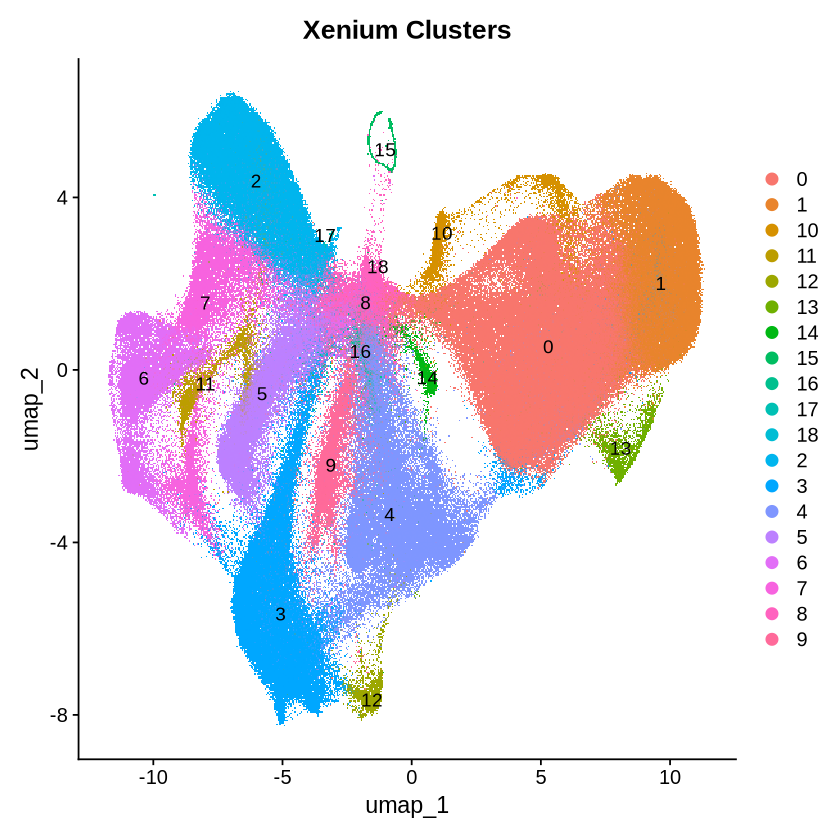


聚类统计:

     0      1     10     11     12     13     14     15     16     17     18 
115241  49668   5871   3918   2822   2407   2292   1413   1338     96      2 
     2      3      4      5      6      7      8      9 
 48217  44897  40881  27423  20900  16971  11536  10718 
✅ Xenium数据处理完成


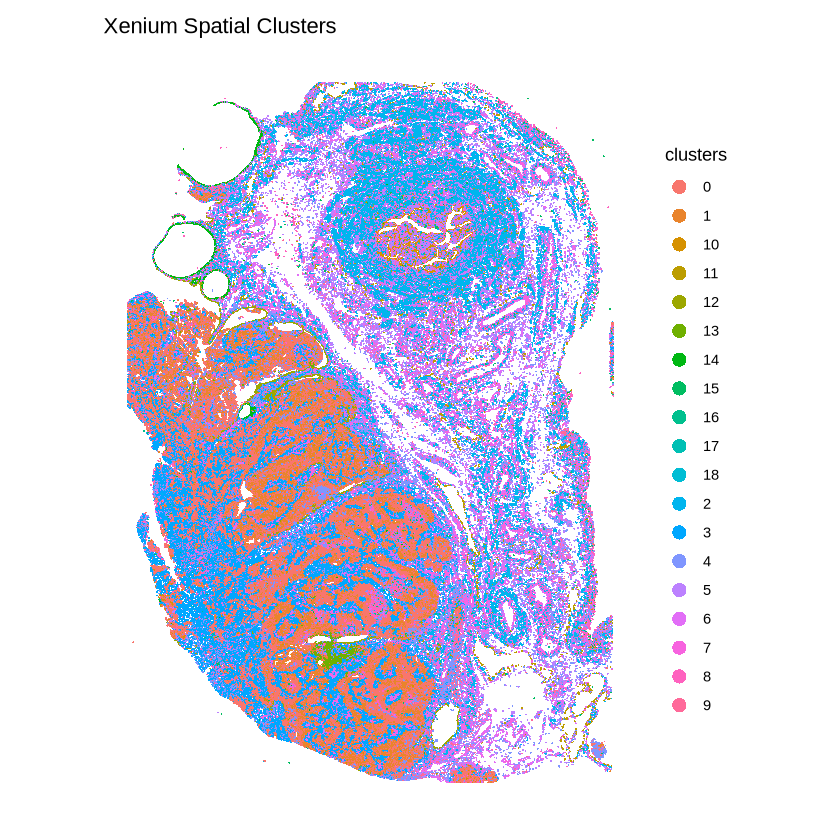

In [6]:
# ============================================
# Cell 6: Xenium数据降维和聚类
# ============================================

cat("🔧 处理Xenium数据（细胞数:", ncol(xenium.obj), "）\n")

DefaultAssay(xenium.obj) <- "Xenium"

xenium.obj <- NormalizeData(xenium.obj) %>%
              FindVariableFeatures() %>%
              ScaleData() %>%
              RunPCA(npcs = params$xenium_npcs, verbose = FALSE) %>%
              RunUMAP(dims = params$xenium_dims, verbose = FALSE) %>%
              FindNeighbors(reduction = "pca", dims = params$xenium_dims) %>%
              FindClusters(resolution = params$xenium_resolution, 
                          cluster.name = params$xenium_cluster_name)

# 可视化
p3 <- DimPlot(xenium.obj, group.by = params$xenium_cluster_name, label = TRUE) + 
      ggtitle("Xenium Clusters")
print(p3)

p4 <- ImageDimPlot(xenium.obj, fov = "fov", group.by = params$xenium_cluster_name, 
                   size = 0.5, dark.background = FALSE) +
      ggtitle("Xenium Spatial Clusters")
print(p4)

# 统计
cat("\n聚类统计:\n")
print(table(xenium.obj$clusters))

cat("✅ Xenium数据处理完成\n")

In [7]:
# ============================================
# Cell 7: 标签转移（核心步骤）- 修正版
# ============================================

# 检查是否已经完成标签转移
if (!"predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    cat("🏷️  开始标签转移...\n")
    
    # 获取共同基因
    flex_xen_common_genes <- intersect(rownames(xenium.obj), rownames(flex_data.obj))
    cat("  共同基因数量:", length(flex_xen_common_genes), "\n")
    
    if (length(flex_xen_common_genes) < 100) {
        warning("共同基因数量较少（<100），标签转移效果可能不佳")
    }
    
    # 创建Flex子集
    cat("  创建Flex子集...\n")
    flex_subset <- CreateSeuratObject(
        counts = flex_data.obj[["RNA"]]$counts[flex_xen_common_genes,],
        meta = flex_data.obj@meta.data
    ) %>%
        NormalizeData() %>%
        FindVariableFeatures() %>%
        ScaleData() %>%
        RunPCA(verbose = FALSE)
    
    # 将counts转回内存格式
    cat("  准备数据...\n")
    flex_data.obj[["RNA"]]$counts <- as(flex_data.obj[["RNA"]]$counts, "dgCMatrix")
    xenium.obj[["Xenium"]]$counts <- as(xenium.obj[["Xenium"]]$counts, "dgCMatrix")
    
    # 寻找锚点
    cat("  寻找锚点（这可能需要一些时间）...\n")
    anchors_from_flex <- FindTransferAnchors(
        reference = flex_subset,
        query = xenium.obj,
        features = flex_xen_common_genes,
        dims = params$transfer_dims,
        reference.reduction = "pca"
    )
    
    # 转移标签
    cat("  转移标签...\n")
    label_transfer <- TransferData(
        anchorset = anchors_from_flex,
        refdata = flex_subset$cell_type,
        dims = params$transfer_dims
    )
    
    # 查看返回的数据结构
    cat("  TransferData 返回的列名:", paste(colnames(label_transfer), collapse = ", "), "\n")
    
    # 正确添加预测结果（添加整个数据框）
    # 方法1：直接添加整个数据框（会同时添加 predicted.id 和 predicted.id.score）
    xenium.obj <- AddMetaData(xenium.obj, metadata = label_transfer)
    
    # 验证是否成功添加
    cat("  添加后的列名:", 
        paste(grep("predicted", colnames(xenium.obj@meta.data), value = TRUE), collapse = ", "), "\n")
    
    # 创建完整标签列的别名（可选，用于后续一致性）
    if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
        xenium.obj@meta.data$predicted.id_full <- xenium.obj@meta.data$predicted.id
    }
    if ("predicted.id.score" %in% colnames(xenium.obj@meta.data)) {
        xenium.obj@meta.data$predicted.id_full.score <- xenium.obj@meta.data$predicted.id.score
    }
    
    cat("✅ 标签转移完成\n")
    cat("\n预测细胞类型分布:\n")
    print(table(xenium.obj$predicted.id))
    
    # 显示预测分数统计
    if ("predicted.id.score" %in% colnames(xenium.obj@meta.data)) {
        cat("\n预测分数统计:\n")
        print(summary(xenium.obj$predicted.id.score))
    }
    
} else {
    cat("✅ 标签转移结果已存在，跳过\n")
    cat("当前预测相关列:", 
        paste(grep("predicted", colnames(xenium.obj@meta.data), value = TRUE), collapse = ", "), "\n")
}

🏷️  开始标签转移...
  共同基因数量: 4912 
  创建Flex子集...


Normalizing layer: counts

Finding variable features for layer counts



  准备数据...
  寻找锚点（这可能需要一些时间）...


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 30971 anchors



  转移标签...


Finding integration vectors

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Finding integration vector weights

Predicting cell labels



  TransferData 返回的列名: predicted.id, prediction.score.Tumor.Associated.Fibroblasts, prediction.score.Endothelial.Cells, prediction.score.Stromal.Associated.Fibroblasts, prediction.score.T...NK.Cells, prediction.score.Malignant.Cells.Lining.Cyst, prediction.score.Proliferative.Tumor.Cells, prediction.score.Tumor.Cells, prediction.score.Pericytes, prediction.score.Granulosa.Cells, prediction.score.Macrophages, prediction.score.Smooth.Muscle.Cells, prediction.score.VEGFA..Tumor.Cells, prediction.score.MT.High..Jun..Fos..Tumor.Cells, prediction.score.Fallopian.Tube.Epithelium, prediction.score.Inflammatory.Tumor.Cells, prediction.score.Ciliated.Epithelial.Cells, prediction.score.max 
  添加后的列名: predicted.id 
✅ 标签转移完成

预测细胞类型分布:

     Ciliated Epithelial Cells              Endothelial Cells 
                          1476                          20252 
     Fallopian Tube Epithelium                Granulosa Cells 
                          2998                           1882 
      Inflammat

📊 绘制预测结果...


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



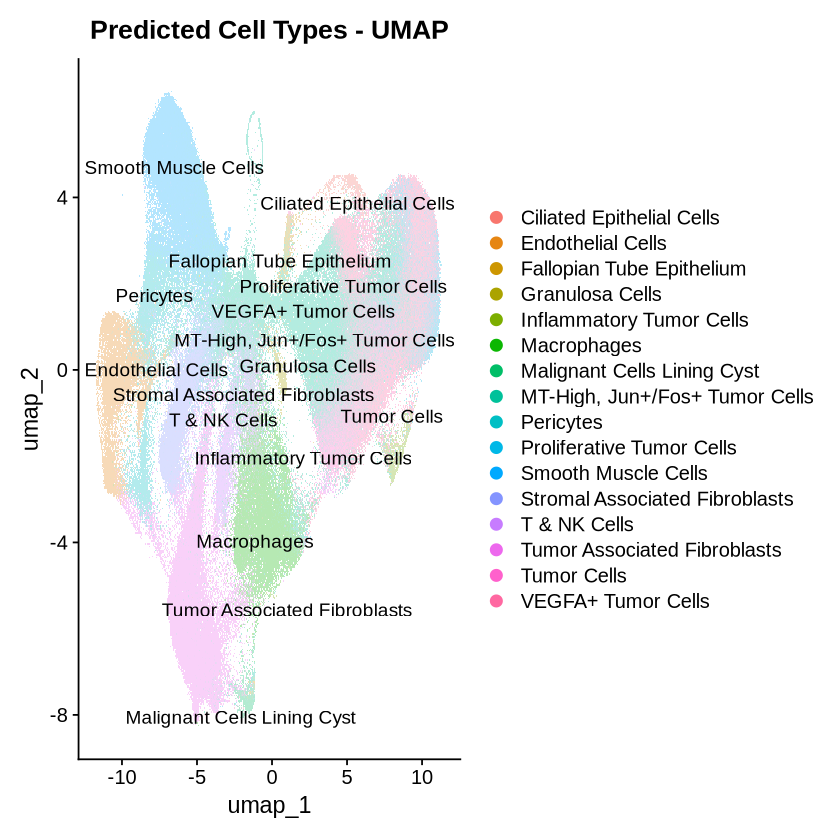


📈 预测分数分析...
  找到 17 个预测分数列
  预测分数统计:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.18    0.65    0.88    0.81    0.99    1.00  163563 


Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `min_score = min(prediction_score, na.rm = TRUE)`.
ℹ In group 6: `predicted.id = "MT-High, Jun+/Fos+ Tumor Cells"`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”



📊 按细胞类型的预测分数统计:
# A tibble: 16 × 6
   predicted.id              mean_score median_score min_score max_score n_cells
   <chr>                          <dbl>        <dbl>     <dbl>     <dbl>   <int>
 1 Endothelial Cells              0.935        1         0.255         1   20252
 2 Granulosa Cells                0.903        1         0.253         1    1882
 3 Tumor Associated Fibrobl…      0.924        0.998     0.187         1   48640
 4 Macrophages                    0.888        0.978     0.236         1   27999
 5 Ciliated Epithelial Cells      0.819        0.944     0.258         1    1476
 6 Stromal Associated Fibro…      0.822        0.889     0.215         1   24975
 7 Smooth Muscle Cells            0.799        0.826     0.190         1   48419
 8 Fallopian Tube Epithelium      0.714        0.743     0.192         1    2998
 9 Inflammatory Tumor Cells       0.722        0.742     0.237         1    1402
10 Malignant Cells Lining C…      0.691        0.719     0.194         1 

Warning message:
“Removed 163563 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 163563 rows containing non-finite outside the scale range
(`stat_summary()`).”


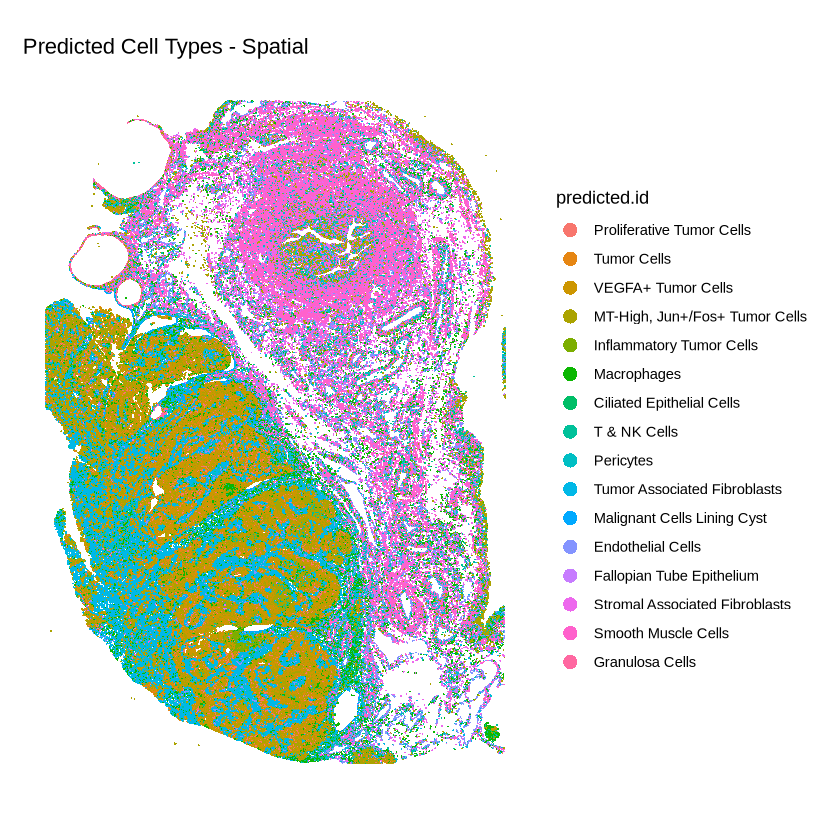

Warning message:
“Removed 163563 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


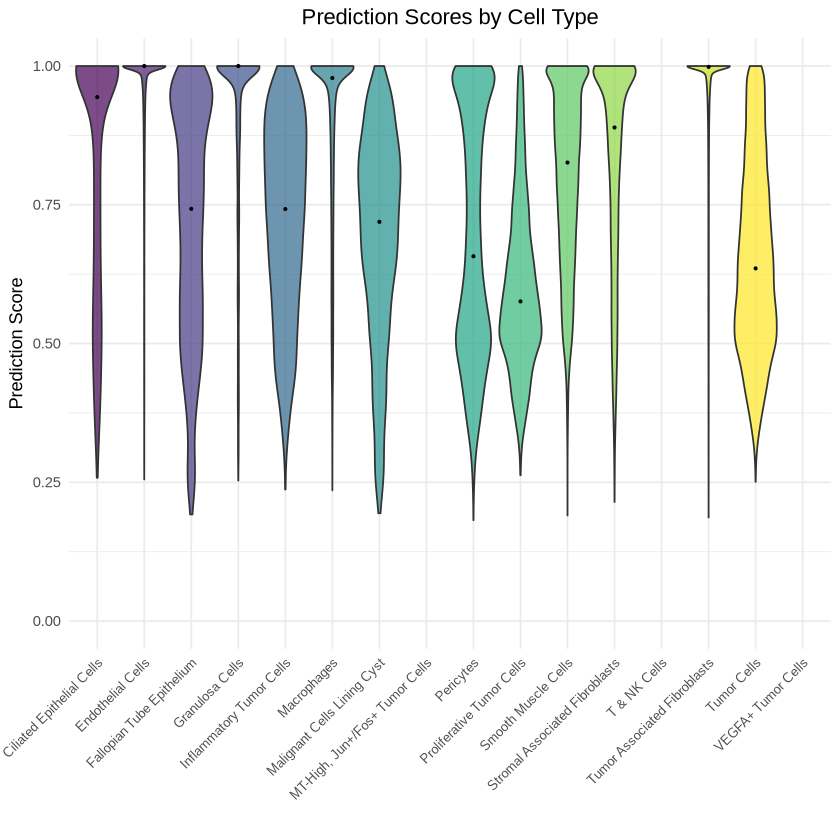


⚠️ 预测分数 < 0.5 的细胞数量: 23399 (5.8%)

✅ 可视化完成


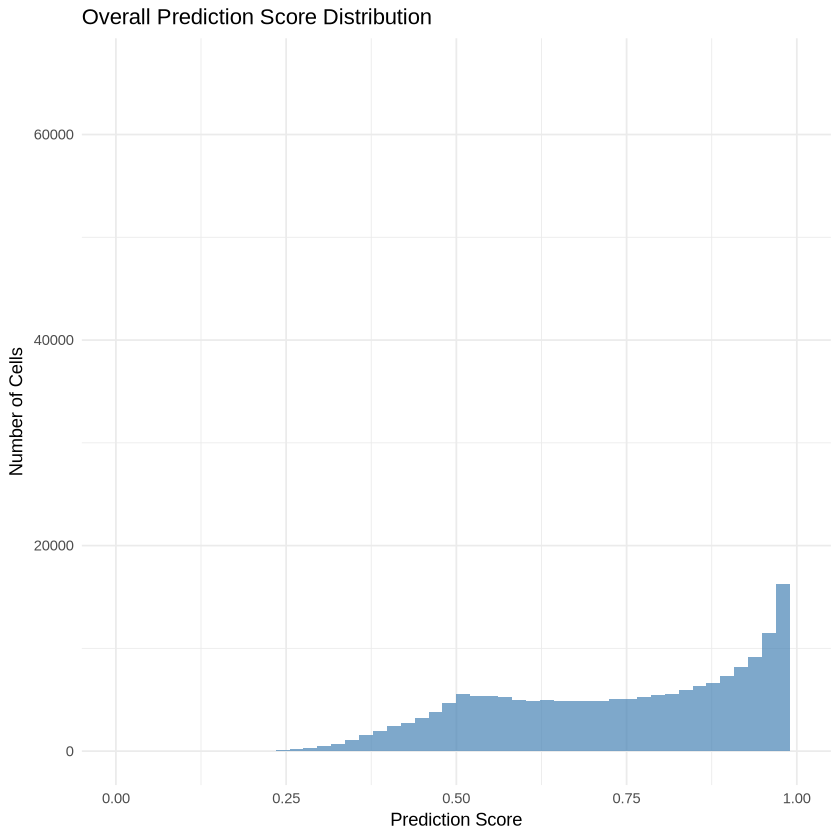

In [ ]:
# ============================================
# Cell 8: 可视化标签转移结果
# ============================================

if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    cat("📊 绘制预测结果...\n")
    
    # 1. UMAP可视化
    p5 <- DimPlot(xenium.obj, reduction = "umap", group.by = "predicted.id", 
                  label = TRUE, pt.size = 0.3, repel = TRUE) + 
          ggtitle("Predicted Cell Types - UMAP")
    print(p5)
    
    # 2. 空间可视化
    p6 <- tryCatch({
        ImageDimPlot(xenium.obj, fov = "fov", group.by = "predicted.id", 
                     size = 0.5, dark.background = FALSE) +
            ggtitle("Predicted Cell Types - Spatial")
    }, error = function(e) {
        cat("    空间可视化失败:", e$message, "\n")
        return(NULL)
    })
    if (!is.null(p6)) print(p6)
    
    # 3. 预测分数处理
    # 找出所有预测分数列（格式：prediction.score.xxx）
    score_cols <- grep("prediction\\.score\\.", colnames(xenium.obj@meta.data), value = TRUE)
    
    if (length(score_cols) > 0) {
        cat("\n📈 预测分数分析...\n")
        cat("  找到", length(score_cols), "个预测分数列\n")
        
        # 为每个细胞找到其预测类型的分数（最大分数）
        # 方法：对于每个细胞，从对应的预测类型列中提取分数
        get_max_score <- function(row) {
            cell_type <- row["predicted.id"]
            score_col <- paste0("prediction.score.", gsub(" ", ".", cell_type))
            if (score_col %in% names(row)) {
                return(as.numeric(row[score_col]))
            } else {
                return(NA)
            }
        }
        
        # 计算每个细胞的预测分数（其预测类型的分数）
        xenium.obj@meta.data$prediction_score <- apply(
            xenium.obj@meta.data, 1, get_max_score
        )
        
        cat("  预测分数统计:\n")
        print(summary(xenium.obj@meta.data$prediction_score))
        
        # 按细胞类型统计分数
        score_stats <- xenium.obj@meta.data %>%
            group_by(predicted.id) %>%
            summarise(
                mean_score = mean(prediction_score, na.rm = TRUE),
                median_score = median(prediction_score, na.rm = TRUE),
                min_score = min(prediction_score, na.rm = TRUE),
                max_score = max(prediction_score, na.rm = TRUE),
                n_cells = n()
            ) %>%
            arrange(desc(median_score))
        
        cat("\n📊 按细胞类型的预测分数统计:\n")
        print(score_stats)
        
        # 绘制小提琴图
        p7 <- ggplot(xenium.obj@meta.data, 
                     aes(x = predicted.id, y = prediction_score, fill = predicted.id)) +
            geom_violin(scale = "width", trim = TRUE) +
            stat_summary(fun = median, geom = "point", size = 0.5, color = "black") +
            scale_fill_viridis_d(alpha = 0.7) +
            theme_minimal() +
            theme(legend.position = "none",
                  axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
                  plot.title = element_text(hjust = 0.5)) +
            ggtitle("Prediction Scores by Cell Type") +
            xlab("") + ylab("Prediction Score") +
            ylim(0, 1)
        print(p7)
        
        # 总体分数分布直方图
        p8 <- ggplot(xenium.obj@meta.data, aes(x = prediction_score)) +
            geom_histogram(bins = 50, fill = "steelblue", alpha = 0.7) +
            theme_minimal() +
            ggtitle("Overall Prediction Score Distribution") +
            xlab("Prediction Score") + ylab("Number of Cells") +
            xlim(0, 1)
        print(p8)
        
        # 可选：显示低质量预测的细胞（分数 < 0.5）
        low_score_cells <- sum(xenium.obj@meta.data$prediction_score < 0.5, na.rm = TRUE)
        cat(sprintf("\n⚠️ 预测分数 < 0.5 的细胞数量: %d (%.1f%%)\n", 
                    low_score_cells, low_score_cells / ncol(xenium.obj) * 100))
        
    } else {
        cat("\n⚠️ 未找到预测分数列，跳过分数分布图\n")
        cat("  当前元数据列名中包含 'score' 的:\n")
        score_cols_found <- grep("score", colnames(xenium.obj@meta.data), value = TRUE, ignore.case = TRUE)
        print(score_cols_found)
    }
    
    cat("\n✅ 可视化完成\n")
    
} else {
    cat("⚠️ 未找到预测结果，请先运行Cell 7\n")
}

In [19]:
# ============================================
# Cell 9: 导出结果（映射表版 - 100%一致性）
# ============================================

if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    cat("📤 正在导出结果...\n")
    
    # 准备基础数据
    export_df <- xenium.obj@meta.data %>%
        rownames_to_column(var = "cell_id")
    
    # 1. 基础列
    base_cols <- c("cell_id")
    
    # 2. 添加聚类列
    if (params$xenium_cluster_name %in% colnames(export_df)) {
        base_cols <- c(base_cols, "cluster")
        export_df$cluster <- export_df[[params$xenium_cluster_name]]
    }
    
    # 3. 添加预测细胞类型
    base_cols <- c(base_cols, "predicted_cell_type")
    export_df$predicted_cell_type <- export_df$predicted.id
    
    # 4. 处理预测分数
    score_cols <- grep("prediction\\.score\\.", colnames(export_df), value = TRUE)
    
    if (length(score_cols) > 0) {
        cat("  找到", length(score_cols), "个预测分数列\n")
        
        # ========== 方法1：使用映射表计算预测分数 ==========
        get_prediction_score_mapped <- function(row) {
            cell_type <- row["predicted_cell_type"]
            if (!is.na(cell_type) && cell_type != "") {
                # 使用反向映射获取分数列名
                if (cell_type %in% names(reverse_mapping)) {
                    score_col <- paste0("prediction.score.", reverse_mapping[cell_type])
                    if (score_col %in% names(row)) {
                        return(as.numeric(row[score_col]))
                    }
                }
            }
            return(NA_real_)
        }
        
        cat("  正在计算预测分数（使用映射表）...\n")
        export_df$prediction_score <- apply(export_df, 1, get_prediction_score_mapped)
        base_cols <- c(base_cols, "prediction_score")
        
        # 统计有效分数
        valid_scores <- export_df$prediction_score[!is.na(export_df$prediction_score)]
        cat("  有效分数细胞数:", length(valid_scores), "/", nrow(export_df), 
            " (", round(length(valid_scores)/nrow(export_df)*100, 1), "%)\n", sep = "")
        
        cat("  预测分数统计:\n")
        print(summary(valid_scores))
        
        # ========== 方法2：使用映射表获取最高分类型 ==========
        get_max_score_type_mapped <- function(row) {
            scores <- as.numeric(row[score_cols])
            if (all(is.na(scores))) return(NA)
            max_idx <- which.max(scores)
            if (length(max_idx) > 0) {
                max_type_key <- gsub("prediction.score.", "", score_cols[max_idx])
                # 使用映射表转换为原始格式
                if (max_type_key %in% names(cell_type_mapping)) {
                    return(cell_type_mapping[max_type_key])
                } else {
                    # 后备方案：尝试自动转换
                    converted <- max_type_key %>%
                        gsub("\\.\\.", ", ", .) %>%
                        gsub("\\.", " ", .)
                    return(converted)
                }
            }
            return(NA)
        }
        
        cat("  正在计算最高分类型（使用映射表）...\n")
        export_df$max_score_type <- apply(export_df, 1, get_max_score_type_mapped)
        base_cols <- c(base_cols, "max_score_type")
        
        # ========== 检查预测一致性 ==========
        export_df$prediction_consistent <- export_df$predicted_cell_type == export_df$max_score_type
        base_cols <- c(base_cols, "prediction_consistent")
        
        consistent_count <- sum(export_df$prediction_consistent, na.rm = TRUE)
        cat("  预测一致性: ", consistent_count, "/", nrow(export_df), 
            " (", round(consistent_count / nrow(export_df) * 100, 1), "%)\n", sep = "")
        
        # ========== 详细分析不一致的情况 ==========
        if (consistent_count < nrow(export_df)) {
            inconsistent_df <- export_df[!export_df$prediction_consistent & !is.na(export_df$prediction_consistent), ]
            cat("\n⚠️ 发现", nrow(inconsistent_df), "个不一致的细胞\n")
            cat("  不一致类型示例:\n")
            inconsistent_summary <- inconsistent_df %>%
                group_by(predicted_cell_type, max_score_type) %>%
                summarise(count = n(), .groups = 'drop') %>%
                arrange(desc(count)) %>%
                head(10)
            print(inconsistent_summary)
        }
        
    } else {
        cat("  ⚠️ 未找到预测分数列\n")
    }
    
    # 5. 选择要导出的列
    available_cols <- base_cols[base_cols %in% colnames(export_df)]
    cell_groups <- export_df %>% select(all_of(available_cols))
    
    # 6. 写入基础CSV
    write.csv(cell_groups, paths$output_csv, row.names = FALSE)
    cat("\n✅ 结果已导出到:", paths$output_csv, "\n")
    cat("  导出列数:", ncol(cell_groups), "\n")
    cat("  导出细胞数:", nrow(cell_groups), "\n")
    
    # 显示预览
    cat("\n📊 文件预览（前15行）:\n")
    print(head(cell_groups, 15))
    
    # 7. 保存完整Seurat对象
    saveRDS(xenium.obj, paths$output_rds)
    cat("\n✅ 完整Seurat对象已保存:", paths$output_rds, "\n")
    
    # 8. 保存包含所有预测分数的完整CSV
    if (length(score_cols) > 0) {
        full_export <- export_df %>%
            select(cell_id, predicted_cell_type, prediction_score, 
                   max_score_type, prediction_consistent, all_of(score_cols))
        
        write.csv(full_export, paths$output_full_csv, row.names = FALSE)
        cat("✅ 完整预测分数文件已保存:", paths$output_full_csv, "\n")
    }
    
    # 9. 保存Flex参考对象
    if (params$save_intermediate && exists("flex_data.obj")) {
        saveRDS(flex_data.obj, paths$output_flex_rds)
        cat("✅ Flex参考对象已保存:", paths$output_flex_rds, "\n")
    }
    
    # 10. 生成详细统计报告
    cat("\n")
    cat(paste(rep("━", 60), collapse = ""), "\n")
    cat("📊 预测结果详细统计报告\n")
    cat(paste(rep("━", 60), collapse = ""), "\n")
    
    # 打开文件连接
    sink(paths$output_stats)
    
    cat("预测结果统计报告\n")
    cat("生成时间:", Sys.time(), "\n")
    cat("总细胞数:", nrow(export_df), "\n")
    cat(paste(rep("=", 60), collapse = ""), "\n\n")
    
    # 1. 细胞类型分布
    cat("📈 1. 预测细胞类型分布\n")
    cat(paste(rep("-", 40), collapse = ""), "\n")
    type_counts <- sort(table(export_df$predicted_cell_type), decreasing = TRUE)
    print(type_counts)
    
    # 2. 预测分数统计
    if ("prediction_score" %in% colnames(export_df)) {
        valid_scores <- export_df$prediction_score[!is.na(export_df$prediction_score)]
        cat("\n📈 2. 预测分数统计（有效分数: N=", length(valid_scores), "）\n", sep = "")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        print(summary(valid_scores))
        
        cat("\n📈 3. 按细胞类型的预测分数统计\n")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        score_by_type <- export_df %>%
            filter(!is.na(prediction_score)) %>%
            group_by(predicted_cell_type) %>%
            summarise(
                n_cells = n(),
                mean_score = mean(prediction_score, na.rm = TRUE),
                median_score = median(prediction_score, na.rm = TRUE),
                sd_score = sd(prediction_score, na.rm = TRUE),
                min_score = min(prediction_score, na.rm = TRUE),
                max_score = max(prediction_score, na.rm = TRUE),
                .groups = 'drop'
            ) %>%
            arrange(desc(mean_score))
        print(score_by_type)
    }
    
    # 4. 一致性统计
    if ("prediction_consistent" %in% colnames(export_df)) {
        cat("\n📈 4. 预测一致性统计\n")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        consistent_count <- sum(export_df$prediction_consistent, na.rm = TRUE)
        total_valid <- sum(!is.na(export_df$prediction_consistent))
        cat("  一致细胞数: ", consistent_count, "\n")
        cat("  不一致细胞数: ", total_valid - consistent_count, "\n")
        cat("  一致率: ", round(consistent_count / total_valid * 100, 2), "%\n", sep = "")
        
        # 按细胞类型统计一致性
        cat("\n📈 5. 按细胞类型的一致性统计\n")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        consistency_by_type <- export_df %>%
            filter(!is.na(prediction_consistent)) %>%
            group_by(predicted_cell_type) %>%
            summarise(
                n_cells = n(),
                consistent = sum(prediction_consistent, na.rm = TRUE),
                consistency_rate = consistent / n() * 100,
                .groups = 'drop'
            ) %>%
            arrange(desc(consistency_rate))
        print(consistency_by_type)
        
        # 如果不一致，显示具体案例
        inconsistent_cases <- export_df %>%
            filter(!prediction_consistent & !is.na(prediction_consistent)) %>%
            select(cell_id, predicted_cell_type, max_score_type, prediction_score) %>%
            head(20)
        
        if (nrow(inconsistent_cases) > 0) {
            cat("\n📈 6. 不一致案例示例（前20个）\n")
            cat(paste(rep("-", 40), collapse = ""), "\n")
            print(inconsistent_cases)
        }
    }
    
    sink()
    
    cat("\n✅ 详细统计报告已保存:", paths$output_stats, "\n")
    
    # 在控制台显示摘要
    cat("\n", paste(rep("━", 60), collapse = ""), "\n")
    cat("📊 结果摘要\n")
    cat(paste(rep("━", 60), collapse = ""), "\n")
    cat("  总细胞数:", nrow(export_df), "\n")
    cat("  有效分数细胞数:", length(valid_scores), "\n")
    cat("  预测一致性: ", round(consistent_count / total_valid * 100, 1), "%\n", sep = "")
    cat(paste(rep("━", 60), collapse = ""), "\n")
    cat("✅ 导出完成\n")
    
} else {
    cat("⚠️ 未找到预测结果，请先运行Cell 7\n")
}

📤 正在导出结果...
  找到 17 个预测分数列
  正在计算预测分数（使用映射表）...
  有效分数细胞数:406611/406611 (100%)
  预测分数统计:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1817  0.5976  0.7913  0.7651  0.9603  1.0000 
  正在计算最高分类型（使用映射表）...
  预测一致性: 405572/406611 (99.7%)

⚠️ 发现 1039 个不一致的细胞
  不一致类型示例:
# A tibble: 1 × 3
  predicted_cell_type         max_score_type count
  <chr>                       <chr>          <int>
1 Malignant Cells Lining Cyst max             1039

✅ 结果已导出到: ./results/cell_groups.csv 
  导出列数: 6 
  导出细胞数: 406611 

📊 文件预览（前15行）:
      cell_id cluster            predicted_cell_type prediction_score
1  aaaaebmm-1       1      Proliferative Tumor Cells        0.8309077
2  aaaafhpp-1       0                    Tumor Cells        0.5043233
3  aaaahcem-1       1             VEGFA+ Tumor Cells        0.7121357
4  aaaakeoi-1       0 MT-High, Jun+/Fos+ Tumor Cells        0.3982315
5  aaaalald-1       0                    Tumor Cells        0.5978105
6  aaaalomf-1       0             VEGFA+ Tumor Cells     